# 01 — Setup and Toolchain


If you haven't yet, open **`00_Theory_Reference.ipynb`** in a side tab.
It's the shared glossary every notebook (this one included) links into with
`§x.y` pointers. By the end of *this* notebook you'll have a working Python
data‑science stack and a feel for the *three tools you'll meet in every
notebook*: **pandas** (data wrangling), **NumPy** (fast arrays), and
**scikit‑learn** (models).

## Learning objectives

1. Verify your environment is set up correctly.
2. Understand the *shape* of a typical ML workflow in code.
3. Meet the **CEO dataset** — the running example through every notebook.
4. Be comfortable loading a CSV, looking at it, and asking basic questions.

## How this handbook is organised

Every notebook follows the same rhythm so you always know where you are:

| Section | What it is |
|---|---|
| **Plain‑language concept** | The intuition behind the topic, no jargon |
| **Theory cross‑references** | ` §x.y` pointers into the shared theory reference for formulas & definitions |
| **Standard process** | Explore → Feature‑engineer → Train → Diagnose/Validate, heavy on visualisation |
| **Worked example A** | The CEO dataset (continuity with the course) |
| **Worked example B** | A best‑fit open dataset for the topic |
| **A failure case** | Where a plausible approach breaks, so you learn what to watch for |
| **Pitfalls & tips** | What bites people in practice |
| **Exercises** | 3–5 problems, with answers hidden in a collapsible cell |

Each notebook **runs top to bottom** — every code cell already has its output,
so you can read it like a book or re‑run it yourself.

## 1. Environment check

Let's confirm the libraries we need are importable and see their versions. If
any line below throws `ModuleNotFoundError`, install the stack with:

```bash
cd handbook
python3 -m venv .venv
.venv/bin/pip install -r requirements.txt
```

In [1]:
import sys, platform
print("Python: ", sys.version.split()[0], "on", platform.system())
print("Executable: ", sys.executable)
print()

# Core stack
import numpy as np
import pandas as pd
import scipy
import sklearn

# Plotting
import matplotlib
import seaborn as sns

# Stats (for the hypothesis-testing notebook)
import statsmodels

libs = {
 "numpy": np.__version__,
 "pandas": pd.__version__,
 "scipy": scipy.__version__,
 "scikit-learn":sklearn.__version__,
 "matplotlib": matplotlib.__version__,
 "seaborn": sns.__version__,
 "statsmodels": statsmodels.__version__,
}
for name, ver in libs.items():
 print(f" {name:<12} {ver}")
print()
print("All imports succeeded — environment is ready.")

Python:  3.12.3 on Linux
Executable:  /home/anton/Work/machine_learning/handbook/notebooks/.venv/bin/python



 numpy        2.5.1
 pandas       3.0.3
 scipy        1.18.0
 scikit-learn 1.9.0
 matplotlib   3.11.0
 seaborn      0.13.2
 statsmodels  0.14.6

All imports succeeded — environment is ready.


## 2. The three tools you'll meet everywhere

A mental model you can lean on for the whole handbook:

- **pandas** — your spreadsheet. Loads tables, filters rows, makes new columns,
 summarises groups. You'll spend most of your *time* here.
- **NumPy** — the fast math engine underneath pandas and scikit‑learn. You'll
 rarely write it directly, but you'll see it in arrays (`np.array`) and in
 broadcasting tricks.
- **scikit‑learn (sklearn)** — the model zoo. Every algorithm in this handbook
 (regression, k‑NN, trees, forests, SVM, k‑means, …) lives here behind a
 remarkably consistent API.

### The scikit‑learn API in one breath

Almost every sklearn model obeys the same 4‑line pattern:

```python
from sklearn.family import ModelName # 1. import
model = ModelName(hyperparam=value) # 2. instantiate
model.fit(X_train, y_train) # 3. train
model.predict(X_new) # 4. predict
```

That's it. Whether you're doing linear regression or a neural network, the
shape of the code does not change. This is *why* sklearn is so pleasant — once
you know the pattern, swapping models is a one‑line change.

## 3. Meet the CEO dataset

This is the dataset the course ships (`data/ceo_data.csv`, originally from
[harkiolakis.com](https://harkiolakis.com/files/Data.csv)). It is small (60
rows) but it appears in every notebook so the mechanics stay familiar and you
can focus on the *new* idea each week.

**Scenario (fictional but plausible):** a consultancy has surveyed 60 companies
across three sectors. For each company they recorded security investment,
breach history, a security rating, and whether the company is listed on a stock
market. Our recurring question across the handbook:

> *Can we predict whether a company is listed on a stock market (`Stock_Market`
> = Yes/No) from the other variables?*

That makes `Stock_Market` our **target** and everything else a **feature**.

In [2]:
from pathlib import Path

DATA_PATH = Path("data/ceo_data.csv")
ceo = pd.read_csv(DATA_PATH)
ceo.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Banking,Female,Small,17,11,2,Medium,High,13,No
1,Banking,Male,Small,18,12,4,High,Low,9,No
2,Banking,Male,Small,17,12,4,High,Medium,22,No
3,Banking,Male,Small,24,13,1,High,Medium,3,Yes
4,Banking,Male,Small,32,14,3,High,Medium,4,Yes


In [3]:
# Shape: (rows, columns). 60 companies, 10 columns.
ceo.shape

(60, 10)

In [4]:
# What pandas sees for each column: type + non-null counts.
ceo.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sector               60 non-null     str  
 1   CEO_Gender           60 non-null     str  
 2   Size                 60 non-null     str  
 3   Security_Invest      60 non-null     int64
 4   Security_Breach_Att  60 non-null     int64
 5   Succ_Sec_Breaches    60 non-null     int64
 6   Sec_Rating           60 non-null     str  
 7   CEO_Sec_Exp          60 non-null     str  
 8   LOT_in_Business      60 non-null     int64
 9   Stock_Market         60 non-null     str  
dtypes: int64(4), str(6)
memory usage: 6.6 KB


**Reading `.info()` output:** `dtypes` matter — `object` usually means text
(categorical), `int64` means whole numbers. Models can't read text directly, so
notebook **02 (EDA & Feature Engineering)** is dedicated to turning these
categories into numbers.

In [5]:
# Quick numeric summary. Note: only the 3 numeric columns appear here.
ceo.describe()

,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,60.000000,60.000000,60.000000,60.000000
mean,63.516667,54.116667,22.633333,8.600000
std,69.317616,64.302804,23.436150,6.211526
min,12.000000,7.000000,0.000000,1.000000
25%,21.000000,14.000000,3.000000,3.750000
50%,32.000000,35.500000,18.500000,7.500000
75%,88.750000,65.500000,32.250000,13.250000
max,435.000000,321.000000,100.000000,22.000000


In [6]:
# Summary of the categorical columns specifically.
ceo.describe(include="object")

/tmp/ipykernel_2437873/560669912.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ceo.describe(include="object")


,Sector,CEO_Gender,Size,Sec_Rating,CEO_Sec_Exp,Stock_Market
count,60,60,60,60,60,60
unique,3,2,3,3,3,2
top,Banking,Male,Medium,Medium,Low,Yes
freq,20,44,23,22,21,42


In [7]:
# Our target — how balanced is it?
ceo["Stock_Market"].value_counts()

Stock_Market
Yes    42
No     18
Name: count, dtype: int64

**Imbalance flag:** there are roughly 2× more `Yes` than `No`. A model that
always guessed "Yes" would already be ~67% accurate — a useful *baseline* to
beat. We'll come back to this idea in every classification notebook.

## 4. A 30‑second tour of the pandas verbs you'll reuse

You don't need to memorise pandas — you just need to recognise a handful of
verbs that show up constantly. Here they are in action on the CEO data.

In [8]:
# (a) Pick columns: list of names -> DataFrame
ceo[["Sector", "Security_Invest", "Stock_Market"]].head(3)

,Sector,Security_Invest,Stock_Market
0,Banking,17,No
1,Banking,18,No
2,Banking,17,No


In [9]:
# (b) Filter rows with a condition
ceo[ceo["Sector"] == "Banking"].head(3)

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Banking,Female,Small,17,11,2,Medium,High,13,No
1,Banking,Male,Small,18,12,4,High,Low,9,No
2,Banking,Male,Small,17,12,4,High,Medium,22,No


In [10]:
# (c) Make a new column
ceo["breach_success_rate"] = (
 ceo["Succ_Sec_Breaches"] / ceo["Security_Breach_Att"]
)
ceo[["Security_Breach_Att", "Succ_Sec_Breaches", "breach_success_rate"]].head()

,Security_Breach_Att,Succ_Sec_Breaches,breach_success_rate
0,11,2,0.181818
1,12,4,0.333333
2,12,4,0.333333
3,13,1,0.076923
4,14,3,0.214286


In [11]:
# (d) Group + aggregate: "average security invest by sector"
ceo.groupby("Sector")["Security_Invest"].mean().sort_values(ascending=False)

Sector
Hospitality    120.80
Health Care     45.55
Banking         24.20
Name: Security_Invest, dtype: float64

In [12]:
# (e) Pivot table: sector x size, counting rows
pd.crosstab(ceo["Sector"], ceo["Size"])

Size,Large,Medium,Small
Sector,,,
Banking,7,6,7
Health Care,6,9,5
Hospitality,4,8,8


## 5. Your first plot

Plotting is how you *see* your data before modelling it. The convention in this
handbook: use **matplotlib** for fine control, **seaborn** for nice defaults.

A consistent setup cell appears at the top of every notebook:

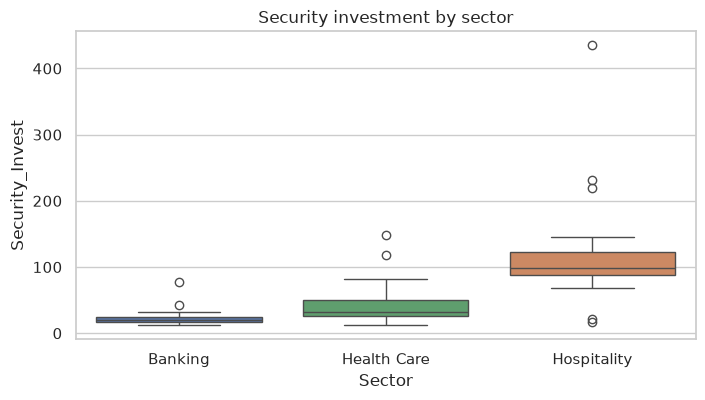

In [13]:
import matplotlib.pyplot as plt

# sensible defaults for the rest of the handbook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)

# Security investment across sectors
order = ceo.groupby("Sector")["Security_Invest"].median().sort_values().index
sns.boxplot(data=ceo, x="Sector", y="Security_Invest", order=order, hue="Sector", legend=False)
plt.title("Security investment by sector")
plt.show()

**Reading a box plot:** the box spans the middle 50% of the data, the line
inside is the median, the whiskers reach to the bulk of the range, and dots are
outliers. Hospitality clearly invests the most — and has the widest spread.

## 6. The standard workflow, in one cell

Almost every notebook in this handbook follows the same skeleton. Here it is,
end‑to‑end, on the CEO data — a **logistic regression** that predicts
`Stock_Market`. Don't worry about the details yet; the point is to see the
*shape*.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Split into features X and target y
X = ceo.drop(columns=["Stock_Market", "breach_success_rate"])
y = (ceo["Stock_Market"] == "Yes").astype(int) # 1 = Yes, 0 = No

# 2. Train/test split (stratify keeps the Yes/No ratio in both halves)
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Preprocess categorical columns, leave numeric alone
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
pre = ColumnTransformer([
 ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

# 4. Bundle preprocessing + model into a pipeline
pipe = Pipeline([
 ("pre", pre),
 ("clf", LogisticRegression(max_iter=1000)),
])

# 5. Fit, predict, score
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f"Accuracy on held-out test set: {accuracy_score(y_test, pred):.2%}")
print(f"Baseline (always guess Yes): {y_test.mean():.2%}")

Accuracy on held-out test set: 60.00%
Baseline (always guess Yes): 73.33%


A real result on a real (tiny) dataset. Note we **compared to a baseline** —
whether the model "is good" only makes sense relative to the dumbest possible
strategy. Notebook 04 goes deep on this kind of validation.

> **Why so much machinery for a 60‑row dataset?** Because the *machinery*
> scales. The same `Pipeline` + `train_test_split` + `fit/predict` pattern
> works unchanged whether your data has 60 rows or 6 million. Learning the
> pattern once on tiny data is the cheapest way to learn it.

## Common pitfalls & tips

- **Always set `random_state`** in splits and models so your results are
 reproducible. Without it, every run gives different numbers and you can't
 debug.
- **Stratify on classification targets** (`stratify=y`) when classes are
 imbalanced — otherwise a small test set can end up with zero of one class.
- **Never look at the test set while engineering features.** Treat it as
 untouchable until the very end. Leakage is the #1 way beginners report
 inflated accuracy.
- **`info()` before `describe()`.** `describe()` only shows numeric columns, so
 you can be lulled into thinking a dataset is fully numeric when it isn't.

## Exercises

1. **Load and profile.** How many unique values does `Sec_Rating` have? Is it
 nominal or ordinal?
2. **Group.** What is the median `LOT_in_Business` for each `Size` category?
3. **Filter + aggregate.** For companies with at least one successful breach
 (`Succ_Sec_Breaches >= 1`), what is the mean `Security_Invest`, broken down
 by `Sector`?
4. **Baseline.** If you always predicted `Stock_Market == "Yes"`, what accuracy
 would you get on the *whole* dataset? Confirm it matches what
 `value_counts()` told you.

<details><summary>Answers (click to expand)</summary>

```python
# 1
ceo["Sec_Rating"].unique() # ['Medium' 'High' 'Low'] -> ordinal

# 2
ceo.groupby("Size")["LOT_in_Business"].median()

# 3
ceo.query("Succ_Sec_Breaches >= 1").groupby("Sector")["Security_Invest"].mean()

# 4
(ceo["Stock_Market"] == "Yes").mean() # ~0.67 -> 67% baseline
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — keep it
 open in a side tab; every notebook links into it.
- Textbook: Boehmke & Greenwell, *Hands‑On Machine Learning with R*, Ch. 1–2 — <https://bradleyboehmke.github.io/HOML/>.
- pandas cheat sheet: <https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf>
- scikit‑learn API conventions: <https://scikit-learn.org/stable/getting_started.html>